# Evaluate IFS with DALES 

In [1]:
import xarray as xr
import os
import dask
import h5netcdf
import scipy
import numpy as np
import pandas as pd
from datetime import timedelta
import datetime
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.colors import TwoSlopeNorm
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker  
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'large',
         'axes.labelsize': 22,
         'axes.titlesize':'large',
         'xtick.labelsize':18,
         'ytick.labelsize':18,
         'figure.figsize':[10,7],
         'figure.titlesize':22}
pylab.rcParams.update(params)

import sys
sys.path.append(".")  # Ensures the current directory is in the Python path
sys.path.append("/home/paaa/python_scripts/")
import my_functions as mfun
from my_classes import DatasetProcessor


In [2]:
dir_in_IFS      = "/perm/paaa/IFS/cabauw"
dir_in_IFS_nemo      = "/perm/paaa/IFS/loobos"
dir_obs         = "/perm/paaa/observations"
dir_dales       = "/perm/paaa/Les/Cases/Catrine/Arseni"

str_time = '2022-05-17T00'
end_time = '2022-05-19T04'

col = ['#D04848','#6895D2','#F3B95F','#59981A']
sty = ['--','-',':']

lead_time = 24

exp_names = [
    ('ctrl'     , 'Cabauw_SPPoff_TKEoff' ,  'Control'),
    ('TKE'      , 'Cabauw_SPPoff_TKEon'  ,  'TKE'),
    ('dryMF'    , 'Cabauw_SPPoff_dryMFv1',  'dry MF'),
    ('ctrl_9km' , 'iq88_ctrl_9km'        ,  '9 km')
]
nemo_exp_names = [
    ('SPP_ctrl',  'iq87_SPP_ctrl'  , 'SPP'       , 'blue'),
    # ('SPP_conv',  'iqgl_SPP_conv'  , 'SPP conv.' , 'red' ),
    # ('SPP_diff',  'iqhl_SPP_diff'  , 'SPP diff.' , 'blue'),
    ('SPP_noIC',  'iqpa_SPP_noIC'  , 'SPP noIC'  , 'green'),
    ('SPP_noIC_conv',  'iqs0_SPP_noIC_conv'  , 'SPP conv noIC'  , 'red'), 
    # ('SPP_noIC_lob',  'iqpa_SPP_noIC_loobos'  , 'SPP noIC'  , 'grey'),
    # ('SPP_noIC_conv_lob',  'iqs0_SPP_noIC_conv_loobos'  , 'SPP conv noIC'  , 'red')
]

#######################################
# Time limits
t0 = datetime.datetime.strptime(str_time, "%Y-%m-%dT%H")
t1 = datetime.datetime.strptime(end_time, "%Y-%m-%dT%H")

hours_day   =[9 ,10,11,12,13,14,15,16,17] # daytime
hours_night =[21,22,23,0 ,1 ,2 ,3 ,4 ,5 ] # nighttime

#######################################
# Configuration for DALES
suffix = '_50km'
# Domain selection
xmin, xmax = 62000, 112000
ymin, ymax = 21000, 71000
xsize = xmax - xmin
ysize = ymax - ymin
dt = 3600 #s


### Open Obs

In [3]:
#### CABAUW ####
################
# Surface
obs_name = "cesar_surface_flux"
datestamp = "2022"

files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_surf_flx    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
obs_surf_flx['time'] = obs_surf_flx['time'].astype('datetime64[ns]') + np.timedelta64(2,'h')
obs_surf_flx = obs_surf_flx.resample(time='1h',label='right').mean()  ## Label right or left??????

# Tower
obs_name = "cesar_tower_flux"
datestamp = "2022"

files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_tower_flx    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
# obs_tower_flx['time'] = obs_tower_flx['time'].astype('datetime64[ns]') + np.timedelta64(2,'h')
# obs_tower_flx = obs_tower_flx.resample(time='1h',label='right').mean()  ## Label right or left??????




### Open IFS

In [4]:
#####  Cabauw Domain #####
# Latitude:   51.72 -  52.22
# Longitude:  4.68  -  5.18
lat_min = 51.72
lat_max = 52.22
lon_min = 4.68
lon_max = 5.18 

In [5]:
srf_nemo_slab_dict = {}
srf_nemo_dict = {}

for exp, exp_longname, _,_ in nemo_exp_names:
    if 'lob' in exp :
        l_time = f't{lead_time}'
        processor_ensemble = DatasetProcessor(exp_longname, dir_in_IFS_nemo + '/eps_nemo',l_time)
        # srf_nemo_slab_dict[exp] = processor_ensemble.get_ds_srf_slab()
        srf_nemo_dict[exp]      = processor_ensemble.get_ds_srf()
        # redefine slab based on domain
        srf_nemo_dict[exp] =  srf_nemo_dict[exp].sel(latitude=slice(lat_max,lat_min),longitude=slice(lon_min,lon_max))
        srf_nemo_slab_dict[exp] = srf_nemo_dict[exp].mean(('latitude', 'longitude'), keep_attrs=True)
    elif 'ctrl' in exp: 
        processor_ensemble = DatasetProcessor(exp_longname, dir_in_IFS + '/eps_nemo')
        srf_nemo_slab_dict[exp] = processor_ensemble.get_ds_srf_slab()
        srf_nemo_dict[exp]      = processor_ensemble.get_ds_srf()
    else  :
        l_time = f't{lead_time}'
        processor_ensemble = DatasetProcessor(exp_longname, dir_in_IFS + '/eps_nemo',l_time)
        srf_nemo_slab_dict[exp] = processor_ensemble.get_ds_srf_slab()
        srf_nemo_dict[exp]      = processor_ensemble.get_ds_srf()
            

srf_fc_slab_dict = {}
srf_fc_dict      = {}
z_fc_slab_dict   = {}
z_fc_dict        = {}

for exp, exp_longanme, label in exp_names:
    processor_fc = DatasetProcessor(exp_longanme, dir_in_IFS)
    srf_fc_slab_dict[exp] = processor_fc.get_ds_srf_slab()
    srf_fc_dict[exp]      = processor_fc.get_ds_srf()
    z_fc_slab_dict[exp]   = processor_fc.get_ds_z_slab()
    z_fc_dict[exp]        = processor_fc.get_ds_z()

Processing iq87_SPP_ctrl
Cannot find .nc file for iq87_SPP_ctrl_z .
Done_____________
Processing iqpa_SPP_noIC
Cannot find .nc file for iqpa_SPP_noIC_z .
Done_____________
Processing iqs0_SPP_noIC_conv
Cannot find .nc file for iqs0_SPP_noIC_conv_z .
Done_____________
Processing Cabauw_SPPoff_TKEoff
trying to convert kg m**-2 to PPM for variable aco2nee
trying to convert kg m**-2 to PPM for variable aco2gpp
trying to convert kg m**-2 to PPM for variable aco2rec
converting kg m**-2 s**-1 to PPM for variable fco2nee, careful!
converting kg m**-2 s**-1 to PPM for variable fco2gpp, careful!
converting kg m**-2 s**-1 to PPM for variable fco2rec, careful!
Units unknown for variable u_flx_conv
Units unknown for variable v_flx_conv
Filling up units for co2_flx_conv
Units unknown for variable u_flx_diff
Units unknown for variable v_flx_diff
Filling up units for co2_flx_diff
Done_____________
Processing Cabauw_SPPoff_TKEon
trying to convert kg m**-2 to PPM for variable aco2nee
trying to convert k

### Open DALES

In [6]:
#####################
### DALES profiles ###
files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'profiles' in f and f.endswith('.nc')]
print('Reading '+str(files))
dales_prof    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':1000})#.sel(time=slice(str_time,end_time))
dales_prof['time'] = dales_prof['time'].astype('datetime64[ns]') - np.timedelta64(1,'D') + np.timedelta64(3,'h') # why -1day and why LT is +3hr ???????
dales_prof = dales_prof.sel(time=slice(str_time,end_time))
## Interpolate half levels to full levels
for var in dales_prof.data_vars:
    if 'zm' in dales_prof[var].coords:
        # Interpolate the variable along the 'zm' coordinate
        dales_prof[var] = dales_prof[var].interp(zm=dales_prof.zt)
    
    ## convert co2 concentration to ppm
    if 'sv' in var:
        dales_prof[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_prof[var]/1000000) # ????????
        dales_prof[var+'_ppm'].attrs['units'] = 'PPM'
        dales_prof[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'

# Drop the unnecessary dimensions and coordinates
dales_prof = dales_prof.drop_dims(["zm"])
dales_prof = dales_prof.sel(zt=slice(0,7000))
dales_prof_hr = dales_prof.resample(time='1h',label='left').mean().chunk({'time':-1,'zt':-1})

Reading ['/perm/paaa/Les/Cases/Catrine/Arseni/profiles.001.nc']


In [7]:
#####################
### DALES 3d fields ###
files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'cabauw_' in f and '_3d' in f and f.endswith('.nc')]
print('Reading '+str(files))
dales_3d    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':24,'zt':8,'xt':190,'yt':289})
dales_3d['time'] = dales_3d['time'].astype('datetime64[ns]') + np.timedelta64(2,'D') + np.timedelta64(2,'h')  # why +2days ?????????
dales_3d = dales_3d.sel(time=slice(str_time,end_time))
for var in dales_3d.data_vars:
    ## convert co2 concentration to ppm
    if 'sv' in var:
        dales_3d[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_3d[var]/1000000) # ???????
        dales_3d[var+'_ppm'].attrs['units'] = 'PPM'
        dales_3d[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'
dales_2d    = dales_3d.mean(('xt','yt'))
dales_2d = dales_2d.chunk({'time':-1,'zt':52})


Reading ['/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_w_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_thl_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_sv004_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_v_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_ql_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_u_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_sv001_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_buoy_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_sv003_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_sv002_3d.nc']


In [8]:
vars = ['sv004','thl','u','v']
ds = {}
for var in vars:
    file = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if var+'_flx_' in f and suffix in f and f.endswith('.nc')]
    print(file)
    dset = xr.open_mfdataset(file, combine='by_coords', engine='h5netcdf')
    ds[var] = dset
    ds[var]['up_flx_frac'] = (ds[var][f"{var}w_filtered"]/ds[var][f"{var}w_unfiltered"])
    # tendnecies
    ds[var]['up_tend']  = ds[var][f"{var}w_filtered"].differentiate('zt') * dt
    ds[var]['tot_tend'] = ds[var][f"{var}w_unfiltered"].differentiate('zt') * dt

#########################
closest_idx_9 = abs(ds['sv004']["filter"] - 9).argmin(dim="klp").values
closest_idx_05 = abs(ds['sv004']["filter"] - 0.5).argmin(dim="klp").values
closest_idx_01 = abs(ds['sv004']["filter"] - 0.1).argmin(dim="klp").values
# Select the corresponding sv004 value
co2_flx_up9km = ds['sv004']['sv004w_filtered'].isel(klp=closest_idx_9)
co2_flx_up05km = ds['sv004']['sv004w_filtered'].isel(klp=closest_idx_05)
co2_flx_up01km = ds['sv004']['sv004w_filtered'].isel(klp=closest_idx_01)
# compute tendencies
co2_tend_up9km = ds['sv004']['up_tend'].isel(klp=closest_idx_9)
co2_tend_up05km = ds['sv004']['up_tend'].isel(klp=closest_idx_05)
co2_tend_up01km = ds['sv004']['up_tend'].isel(klp=closest_idx_01)
#########################

['/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z900.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z4200.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z3200.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z600.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z2200.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z1700.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z1200.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z2700.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z3700.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/sv004_flx_filter_50km_z300.nc']
['/perm/paaa/Les/Cases/Catrine/Arseni/thl_flx_filter_50km_z300.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/thl_flx_filter_50km_z4200.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/thl_flx_filter_50km_z600.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/thl_flx_filter_50km_z3700.nc', '/perm/paaa/Les/Cases/Catrine/A

## Define BLH in DALES as in IFS

In [9]:
def interp_pblh(Ri, zt, threshold=0.25):
    # Difference from threshold
    diff = Ri - threshold

    # Condition: Ri > 0.25
    mask = diff > 0

    # Find index along zt where Ri first exceeds threshold
    ri_ind = mask.argmax(dim="zt")

    # Gather values just before and after the threshold crossing
    ri_low = Ri.isel(zt=ri_ind - 1)
    ri_high = Ri.isel(zt=ri_ind)

    zt_low = zt.isel(zt=ri_ind - 1)
    zt_high = zt.isel(zt=ri_ind)

    # Linear interpolation to where Ri == threshold
    pblh = zt_low + (zt_high - zt_low) * ((threshold - ri_low) / (ri_high - ri_low))

    return pblh

In [10]:
#### Not accurate! you need the surface values! this lowest level is about 12 m ####
thv_surf = dales_prof_hr['thv'].sel(zt=0,method='nearest') +2.5 ####?????????????
z_surf  = dales_prof_hr['zt'].sel(zt=0,method='nearest') -10
u_surf  = dales_prof_hr['u'].sel(zt=0,method='nearest') *0.2
v_surf  = dales_prof_hr['v'].sel(zt=0,method='nearest') *0.2
####################

num = mfun.g/(thv_surf) * (dales_prof_hr['thv'] - (thv_surf)) * (dales_prof_hr['zt']-(z_surf))
den = (dales_prof_hr['u'] - (u_surf))**2 + (dales_prof_hr['v'] - (v_surf))**2

# num = mfun.g/dales_prof_hr['thv'] * (dales_prof_hr['thv'].diff('zt')) * (dales_prof_hr['zt'].diff('zt'))
# den = (dales_prof_hr['u'].diff('zt'))**2 + (dales_prof_hr['v'].diff('zt'))**2

Ri  = num/den 

pblh = interp_pblh(Ri.compute(),dales_prof_hr['zt'],0.25)

### DALES calculate fluxes

In [10]:
dt = 3600 # seconds in 1 hour this is becasue we have 1 DALES snapshot every hour
dales_3d['w_p'] = dales_3d['w'] - dales_2d['w']
for var in ['sv001_ppm','sv004_ppm','thl','u','v']:
    dales_3d[var+'_p']      = dales_3d[var] - dales_2d[var]
    dales_3d[var+'_w']      = dales_3d[var+'_p']*dales_3d['w_p']
    dales_2d[var+'_flx']    = dales_3d[var+'_w'].mean(('xt','yt'))
    dales_2d[var+'_ten']    = dales_2d[var+'_flx'].differentiate('zt') *dt   ##this is istantaneous and is tendency/second! go get the 15 min output and calculate mean over 1 hour!

# Plotting

(-1.0, 2000.0)

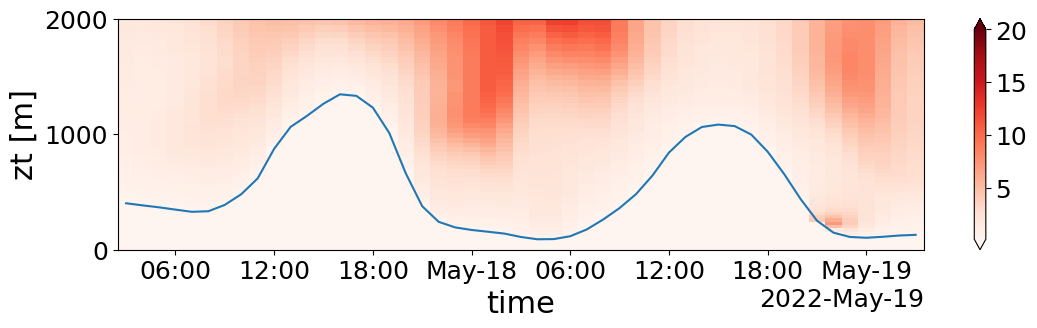

In [11]:
#### check Ri number for BLH ###
plt.figure(figsize=(13,3))
pblh.plot(x='time')
# (Ri-5).plot(x='time',cmap='Reds',vmin=0.1,vmax=10)
Ri.plot(x='time',cmap='Reds',vmin=0.1,vmax=20)
# dales_prof_hr['thv'].plot(x='time',cmap='Reds',vmax=300)
plt.ylim([-1,2000])

In [15]:
nemo_exp_names

[('SPP_ctrl', 'iq87_SPP_ctrl', 'SPP', 'blue'),
 ('SPP_noIC', 'iqpa_SPP_noIC', 'SPP noIC', 'green'),
 ('SPP_noIC_conv', 'iqs0_SPP_noIC_conv', 'SPP conv noIC', 'red')]

(np.float64(19129.0), np.float64(19131.166666666668))

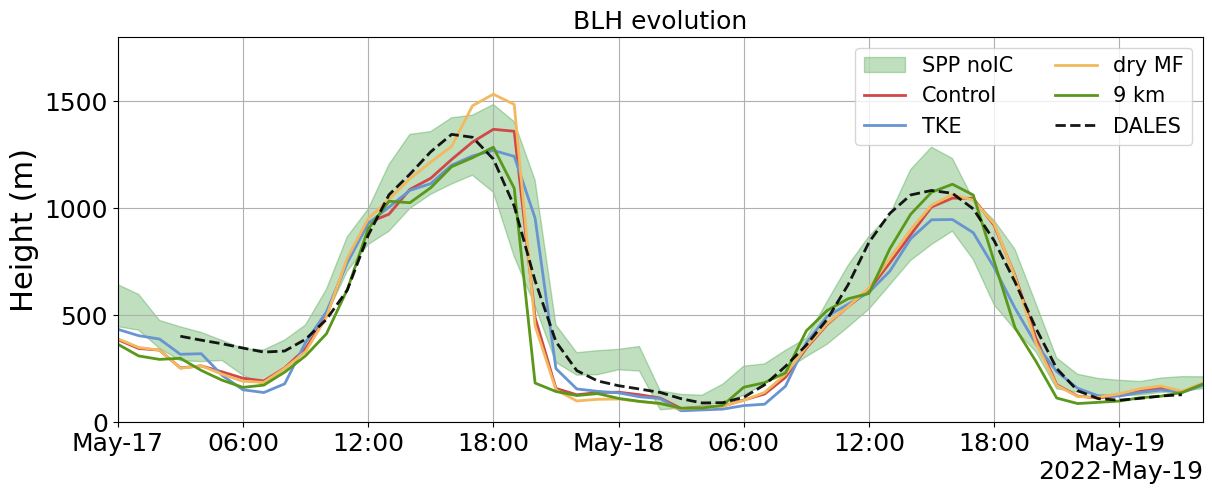

In [17]:
### evolution of the BLH
# Set up the figure
fig, ax = plt.subplots(figsize=(14, 5))

# Plot shaded regions for ensemble runs
for i, (ens_key,_,ens_lab, ens_color) in enumerate(nemo_exp_names[1:2]):
    # # Plot all lines in grey
    # for number in srf_nemo_slab_dict[ens_key]['number']:
    #     srf_nemo_slab_dict[ens_key]['blh'].sel(number=number).plot(x='time', color=ens_color, alpha=0.5, linewidth=0.8, ax=ax)

    blh_min = srf_nemo_slab_dict[ens_key]['blh'].min(dim='number')
    blh_max = srf_nemo_slab_dict[ens_key]['blh'].max(dim='number')
    
    ax.fill_between(
        srf_nemo_slab_dict[ens_key]['time'].values,
        blh_min.values,
        blh_max.values,
        color=ens_color,
        alpha=max(0.12, 0.25 - 0.6 * i),
        label=ens_lab
    )

for (exp,_, label), c in zip(exp_names, col):
    srf_slab = srf_fc_slab_dict[exp]
    # Plot mean line
    srf_slab['blh'].plot(label=label, color=c, lw=2,alpha=1)

pblh.plot(x='time',label='DALES',lw=2,ls='--',c='k',alpha=0.9)

ax.set_title('BLH evolution',fontsize=18)
ax.set_ylabel('Height (m)')
ax.set_xlabel('')
ax.set_ylim([0,1800])
ax.legend(fontsize=15,ncol=2)
plt.grid(True)
ax.set_xlim(t0, t1)

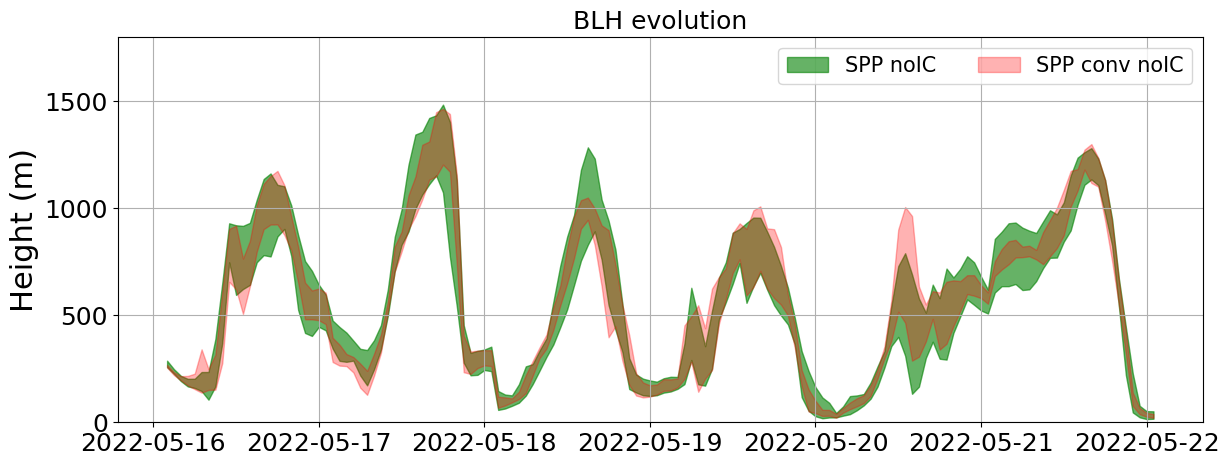

In [65]:
### evolution of the BLH
# Set up the figure
fig, ax = plt.subplots(figsize=(14, 5))

# Plot shaded regions for ensemble runs
for i, (ens_key,_,ens_lab, ens_color) in enumerate(nemo_exp_names[1:3]):
    # # Plot all lines in grey
    # for number in srf_nemo_slab_dict[ens_key]['number']:
    #     srf_nemo_slab_dict[ens_key]['blh'].sel(number=number).plot(x='time', color=ens_color, alpha=0.5, linewidth=0.8, ax=ax)

    blh_min = srf_nemo_slab_dict[ens_key]['blh'].min(dim='number')
    blh_max = srf_nemo_slab_dict[ens_key]['blh'].max(dim='number')
    
    ax.fill_between(
        srf_nemo_slab_dict[ens_key]['time'].values,
        blh_min.values,
        blh_max.values,
        color=ens_color,
        alpha=max(0.12, 0.6 - 0.3 * i),
        label=ens_lab
    )

ax.set_title('BLH evolution',fontsize=18)
ax.set_ylabel('Height (m)')
ax.set_xlabel('')
ax.set_ylim([0,1800])
ax.legend(fontsize=15,ncol=2)
plt.grid(True)
# ax.set_xlim(t0, t1)

In [22]:
srf_slab

<xarray.Dataset> Size: 30kB
Dimensions:      (time: 144)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2022-05-15T03:00:00 ... 2022-05-21...
Data variables: (12/25)
    lai_lv       (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    lai_hv       (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    aco2nee      (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    aco2gpp      (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    aco2rec      (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    fco2nee      (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    ...           ...
    co2          (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    ch4          (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    co           (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    ra           (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    e_WLCH4      (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>
    acc_e_WLCH4  (time) float64 1kB dask.array<chunksize=(144,), meta=np.ndarray>

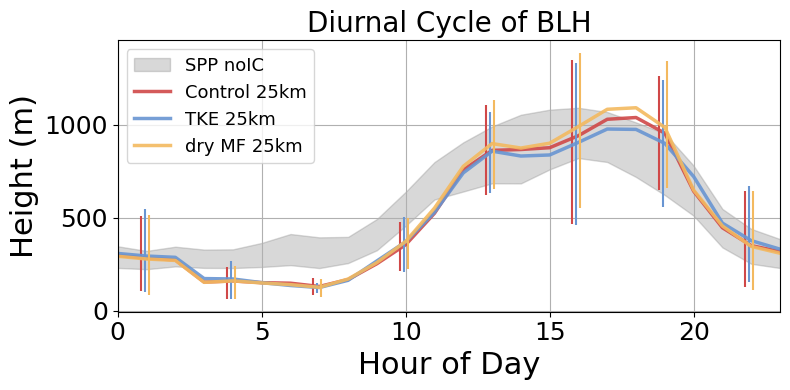

In [21]:
#####   Diurnal cycle of BLH  #####
###################################
plt.figure(figsize=(8, 4))

# Plot shaded spread for each ensemble
for i, (ens_key, _, ens_lab, ens_color) in enumerate([nemo_exp_names[1],]):
    min_member = srf_nemo_slab_dict[ens_key]['blh'].min(dim='number')
    max_member = srf_nemo_slab_dict[ens_key]['blh'].max(dim='number')

    min_by_hour = min_member.groupby('time.hour').mean('time')
    max_by_hour = max_member.groupby('time.hour').mean('time')

    plt.fill_between(
        min_by_hour['hour'].values,
        min_by_hour.values,
        max_by_hour.values,
        color='grey',
        alpha=max(0.05, 0.3 - 0.1 * i),
        label=f'{ens_lab}'
    )

# Offset for percentile bars
offsets = [-0.21, -0.07,+0.07, 0.21]  # small x-axis shifts for the bars
for (exp, _, label), c, dx in zip(exp_names[0:3], col, offsets):
    srf_slab = srf_fc_slab_dict[exp]

    # Group by hour
    grouped = srf_slab['blh'].groupby('time.hour')
    diurnal = grouped.mean()
    p10 = grouped.quantile(0.10)
    p90 = grouped.quantile(0.90)

    # Plot mean line
    diurnal.plot(label=f"{label} 25km", color=c, lw=2.5, alpha=0.9)

    # Plot vertical lines for spread every 3 hours
    for hour in range(1, 24, 3):
        x = hour + dx
        ylow = p10.sel(hour=hour)
        yhigh = p90.sel(hour=hour)
        plt.vlines(x, ylow, yhigh, color=c, lw=1.5)

plt.xlim([0, 23])
plt.xlabel('Hour of Day')
plt.ylabel('Height (m)')
plt.title('Diurnal Cycle of BLH', fontsize=20)
plt.legend(fontsize=13,ncol=1)
plt.grid(True)
plt.tight_layout()

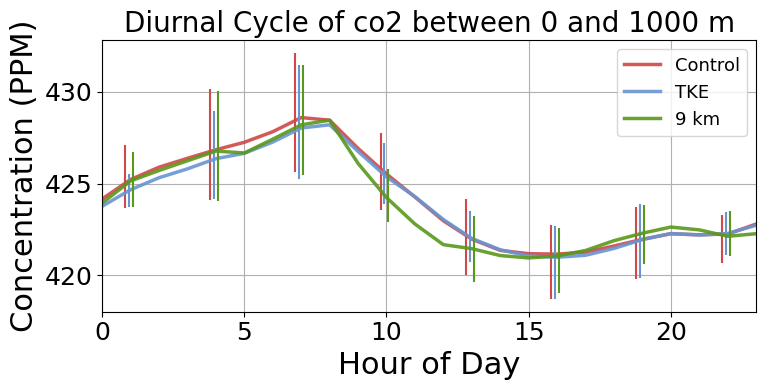

In [89]:
### Diurnal cycle of concentration ###
###################################
var = 'co2'
levels= [0,1000] #m
plt.figure(figsize=(8, 4))

# Offset for percentile bars
offsets = [-0.21, -0.07,+0.07, 0.21]  # small x-axis shifts for the bars
for (exp, _, label), c, dx in zip([exp_names[i] for i in [0, 1, 3]], [col[i] for i in [0, 1, 3]], offsets):
    z_slab = z_fc_slab_dict[exp].sel(height=slice(levels[0],levels[1])).mean('height')

    # Group by hour
    grouped = z_slab[var].groupby('time.hour')
    diurnal = grouped.mean()
    p10 = grouped.quantile(0.10)
    p90 = grouped.quantile(0.90)

    # Plot mean line
    diurnal.plot(label=label, color=c, lw=2.5, alpha=0.9)

    # Plot vertical lines for spread every 3 hours
    for hour in range(1, 24, 3):
        x = hour + dx
        ylow = p10.sel(hour=hour)
        yhigh = p90.sel(hour=hour)
        plt.vlines(x, ylow, yhigh, color=c, lw=1.5)

plt.xlim([0, 23])
# plt.ylim([420, 430])
plt.xlabel('Hour of Day')
plt.ylabel('Concentration (PPM)')
plt.title(f'Diurnal Cycle of {var} between 0 and 1000 m', fontsize=20)
plt.legend(fontsize=13,ncol=1)
plt.grid(True)
plt.tight_layout()

########

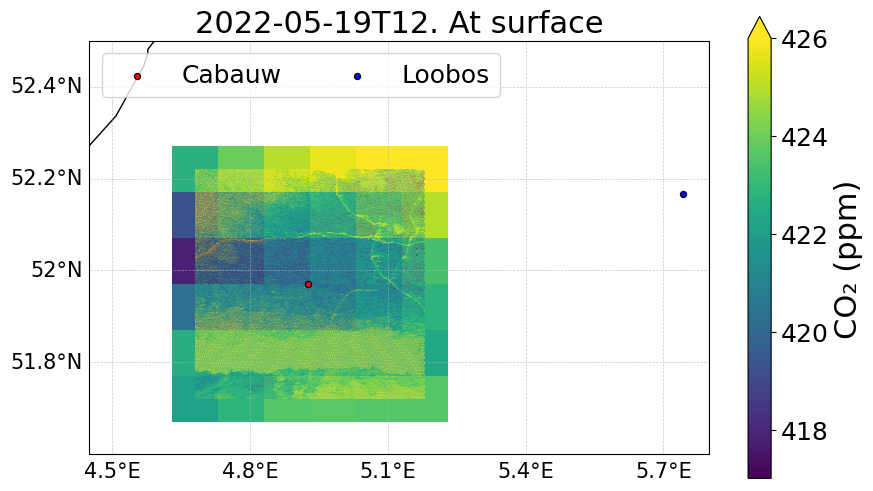

In [ ]:
########  Maps  ########
########################
var_ifs = 'co2_ppm'
var_dales = 'sv004_ppm'
sel_time = '2022-05-19T12'

# Define the projection (PlateCarree is appropriate for lat/lon grids)
projection = ccrs.PlateCarree()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection})

# Plot the data
p = ifs_srf.sel(time=sel_time)[var_ifs].plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis',
                                                           add_colorbar=True,
                                                           cbar_kwargs={'label': f'CO₂ (ppm)'},
                                                           vmin= 417,vmax=426
                                                           )

mesh = ax.pcolormesh(dales_3d['lon'], dales_3d['lat'], dales_3d[var_dales].sel(time=sel_time).sel(zt=0,method='nearest'), cmap='viridis',vmin= 417,vmax=426,
                     alpha=0.4, transform=ccrs.PlateCarree())


# Modify colorbar ticks
cbar = p.colorbar
cbar.locator = ticker.MaxNLocator(5,integer=True)  # Set number of ticks
cbar.update_ticks()

# Add coastlines
ax.coastlines(resolution='10m', linewidth=1)

# Optionally, add country borders for reference
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')

# Set extent to focus on the Netherlands region
# ax.set_extent([3, 7.5, 50.3, 54.5], crs=ccrs.PlateCarree())
ax.set_extent([4.45, 5.8, 51.6, 52.5], crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
gl.top_labels = False  # Remove top labels (optional)
gl.right_labels = False  # Remove right labels (optional)

# Customise tick labels
gl.xlocator = cticker.MaxNLocator(5)  # Adjust number of longitude ticks
gl.ylocator = cticker.MaxNLocator(5)  # Adjust number of latitude ticks
gl.xlabel_style = {"size": 15, "color": "black"}  # Custom style
gl.ylabel_style = {"size": 15, "color": "black"}

# First red dot at (51.971°N, 4.927°E)
ax.scatter(4.927, 51.971, color='red', s=20, marker='o', transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, label='Cabauw')

# Second blue dot at (52° 09' 59.34" N, 5° 44' 36.79" E)
lat2 = 52 + (9 / 60) + (59.34 / 3600)  # Convert to decimal: 52.16648°N
lon2 = 5 + (44 / 60) + (36.79 / 3600)  # Convert to decimal: 5.74355°E

ax.scatter(lon2, lat2, color='blue', s=20, marker='o', transform=ccrs.PlateCarree(), edgecolor='black', linewidth=0.8, label='Loobos')

plt.legend(fontsize=18,loc='upper left',ncol=2)
plt.title(sel_time+'. At surface',fontsize = 22) 
# Show the plot
plt.show()

In [24]:
### Fluxes at 100 m ####
plt.figure(figsize=(18,4))
dales_2d['sv004_ppm_flx'].sel(zt=180,method='nearest').plot(x='time')
obs_tower_flx['WC180'].plot()

KeyboardInterrupt: 

<Figure size 1800x400 with 0 Axes>

Text(0.5, 1.0, 'DALES - Resolved CO2 tendency (from 3d fields)')

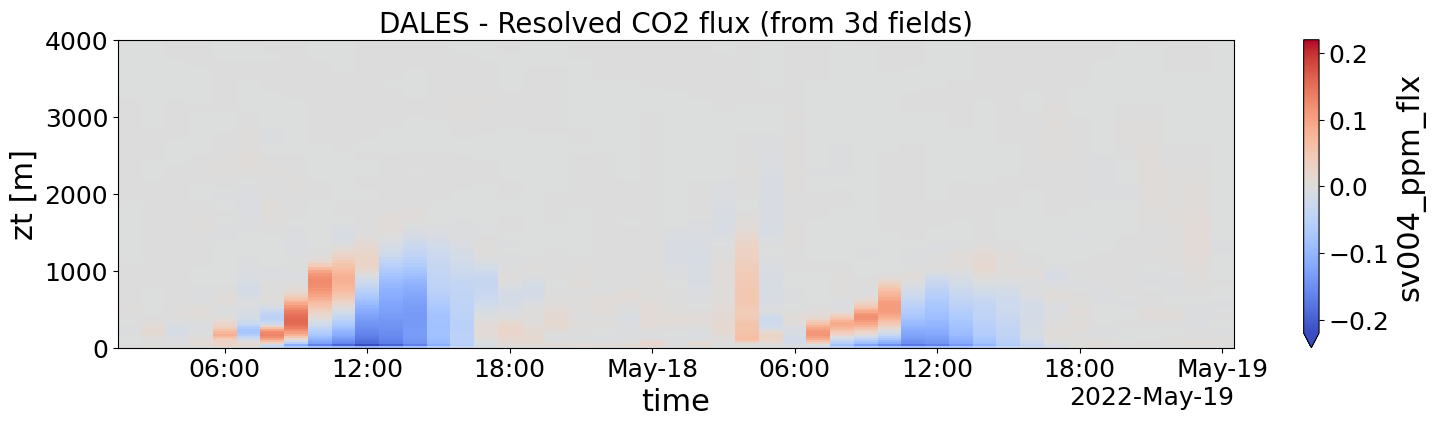

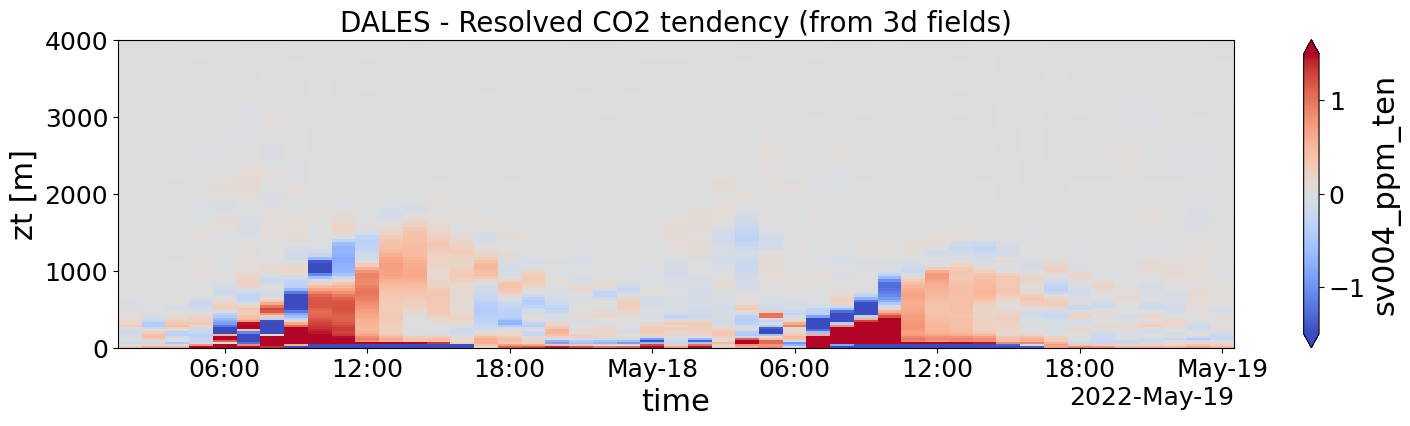

In [34]:
########  From Profiles: means over the full DALES domain  ########
########################
# plt.figure(figsize=(18,4))
# var = 'wsv004t_ppm'
# dales_prof_hr[var].plot(x='time',vmin=-0.22)
# plt.ylim(0,4000)
# plt.title('DALES - Total CO2 flux',fontsize = 20)

##### DALES RESOLVED FLUXES AND TENDENCIES #####

plt.figure(figsize=(18,4))
dales_2d['sv004_ppm_flx'].plot(x='time',vmin=-0.22, cmap='coolwarm')
plt.ylim(0,4000)
plt.title('DALES - Resolved CO2 flux (from 3d fields)',fontsize = 20)

plt.figure(figsize=(18,4))
dales_2d['sv004_ppm_ten'].plot(x='time', cmap='coolwarm',
                               vmin=-1.5
                               )
plt.ylim(0,4000)
plt.title('DALES - Resolved CO2 tendency (from 3d fields)',fontsize = 20)



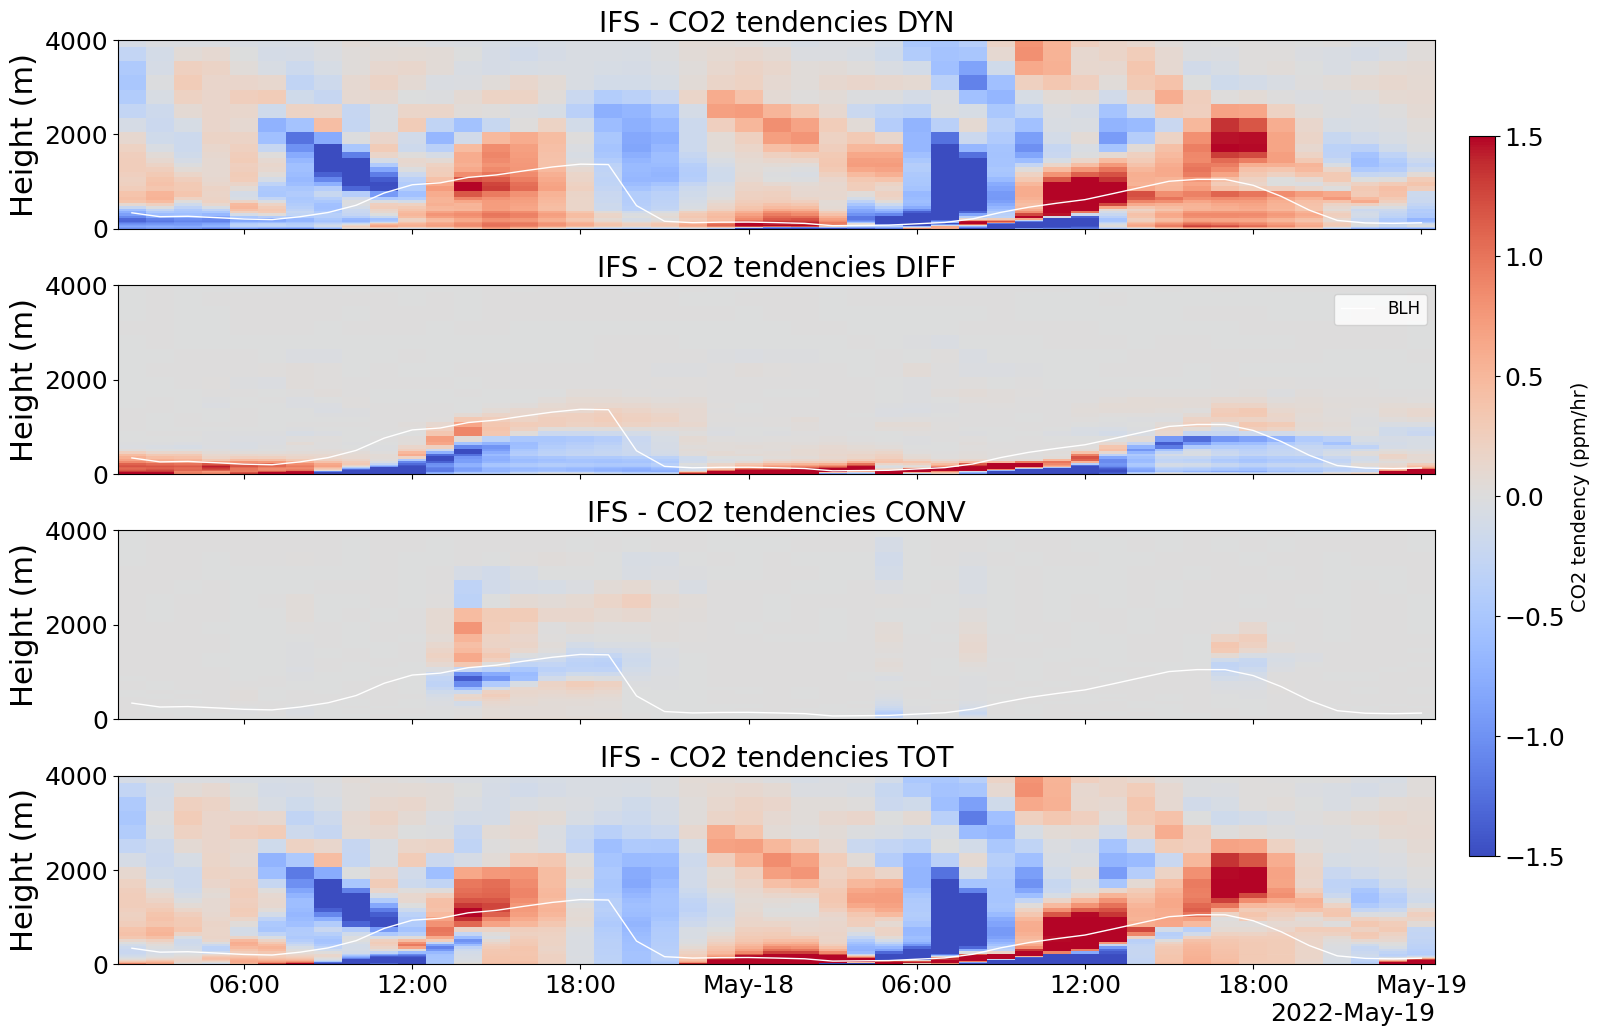

In [27]:
##### IFS TENDENCIES #####

vmin = -1.5
vmax = -vmin
var_dales = 'sv004_ppm'
var_ifs   = 'dco2dt'

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(17, 12))

##### IFS #####
## DYN
ifs_plot = ifs_z_slab[var_ifs+'_dyn_ppm'].plot(ax=axes[0], y='height',
                         vmin=vmin, vmax=vmax, add_colorbar=False, cmap='coolwarm')
ifs_srf_slab['blh'].plot(ax=axes[0], x='time', c='white', lw=1, label='BLH')
axes[0].set_title('IFS - CO2 tendencies DYN', fontsize=20)
## TURB
ifs_z_slab[var_ifs+'_diff_ppm'].plot(ax=axes[1], y='height',
                         vmin=vmin, vmax=vmax, add_colorbar=False, cmap='coolwarm')
ifs_srf_slab['blh'].plot(ax=axes[1], x='time', c='white', lw=1, label='BLH')
axes[1].set_title('IFS - CO2 tendencies DIFF', fontsize=20)
## CONV
ifs_z_slab[var_ifs+'_conv_ppm'].plot(ax=axes[2], y='height',
                         vmin=vmin, vmax=vmax, add_colorbar=False, cmap='coolwarm')
ifs_srf_slab['blh'].plot(ax=axes[2], x='time', c='white', lw=1, label='BLH')
axes[2].set_title('IFS - CO2 tendencies CONV', fontsize=20)
## TOT
ifs_z_slab[var_ifs+'_tot_ppm'].plot(ax=axes[3], y='height',
                         vmin=vmin, vmax=vmax, add_colorbar=False, cmap='coolwarm')
ifs_srf_slab['blh'].plot(ax=axes[3], x='time', c='white', lw=1, label='BLH')
axes[3].set_title('IFS - CO2 tendencies TOT', fontsize=20)

axes[1].legend()

## Common axes formatting
for idy,ax in enumerate(axes):
    ax.set_ylim(0, 4000)
    ax.set_xlabel('')
    ax.set_ylabel('Height (m)')
    if idy<len(axes)-1:
        ax.set_xticklabels([])
        

## Common colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(ifs_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label('CO2 tendency (ppm/hr)', fontsize=14)

## Adjust layout to prevent overlap
fig.subplots_adjust(right=0.9, hspace=0.3)



### Concentration

In [63]:
cloud_mask_ifs   = xr.where(ifs_z_slab['clwc']>0.001,1,np.nan)
cloud_mask_dales = xr.where(dales_2d['ql']>0.1*10**(-4),1,np.nan)

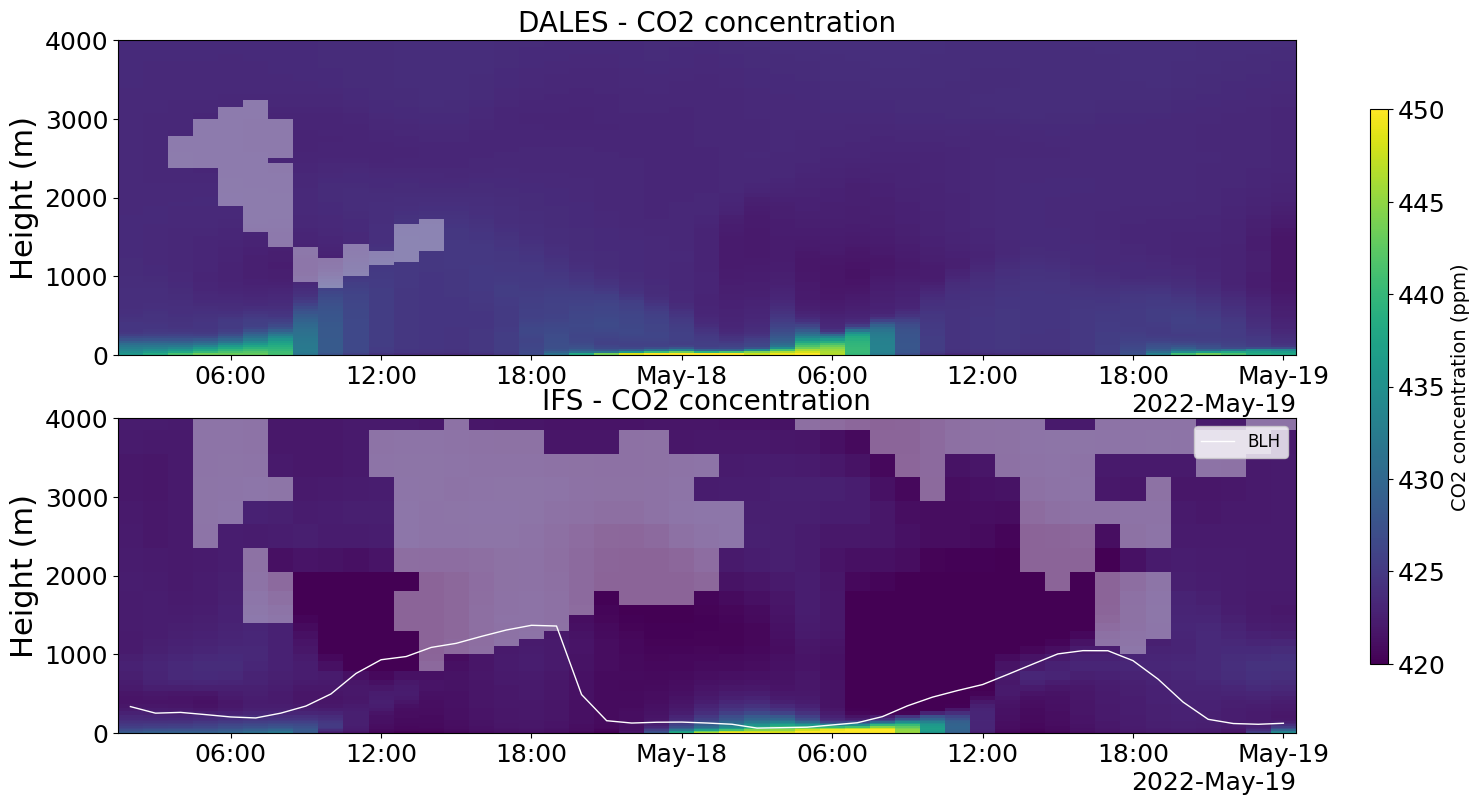

In [67]:
vmin = 420
vmax = 450
var_dales = 'sv004_ppm'
var_ifs   = 'co2_ppm'

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19, 9),
                        #  sharex=True
                         )
## DALES
dales_plot = dales_2d[var_dales].plot(ax=axes[0], x='time'  ,
                         vmin=vmin,vmax=vmax,add_colorbar=False)
cloud_mask_dales.plot(ax=axes[0], y='zt', cmap='Blues_r',
                vmin=0, vmax=0.1,add_colorbar=False, alpha=0.4)
axes[0].set_title('DALES - CO2 concentration',fontsize = 20)

## IFS
ifs_plot = ifs_z_slab[var_ifs].plot(ax=axes[1], y='height',
                         vmin=vmin,vmax=vmax,add_colorbar=False)
cloud_mask_ifs.plot(ax=axes[1], y='height', cmap='Blues_r',
                vmin=0, vmax=0.1,add_colorbar=False, alpha=0.4)
ifs_srf_slab['blh'].plot(ax=axes[1],x='time',c='white',lw=1, label='BLH')
axes[1].set_title('IFS - CO2 concentration',fontsize = 20)

axes[1].legend()

## Common axes
for ax in axes:
    ax.set_ylim(0,4000)
    ax.set_xlabel('')
    ax.set_ylabel('Height (m)')
## Common colorbar
cbar = fig.colorbar(dales_plot, ax=axes, orientation='vertical', shrink=0.8, aspect=30)
cbar.set_label('CO2 concentration (ppm)', fontsize=14)



In [ ]:
############ MEAN PROFILES ############
#######################################

###### CO2 concentration ######
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 7))

### DALES
std_profile = dales_3d['sv004_ppm'].std(('xt', 'yt'))
dales_2d['sv004_ppm'].mean('time').plot(ax=axes[0],
    y='zt',label='DALES',c=col[0],alpha=1,lw=3)
# Add shading for standard deviation
axes[0].fill_betweenx(dales_2d['zt'],  (dales_2d['sv004_ppm'] - std_profile).mean('time'), (dales_2d['sv004_ppm'] + std_profile).mean('time'),
                  color=col[0], alpha=0.3)
### IFS
std_profile = ifs_z['co2_ppm'].std(('latitude', 'longitude'))
ifs_z_slab['co2_ppm'].mean('time').plot(ax=axes[0],
    y='height',label='IFS',c=col[1],lw=3)
axes[0].fill_betweenx(ifs_z_slab['height'], (ifs_z_slab['co2_ppm'] - std_profile).mean('time'), (ifs_z_slab['co2_ppm'] + std_profile).mean('time'),
                  color=col[1], alpha=0.3)
axes[0].set_title('CO2 concentration')
axes[0].legend()

#### normalised by surface value ####
(dales_2d['sv004_ppm']/dales_2d['sv004_ppm'].sel(zt=0,method='nearest')).mean('time').plot(ax=axes[1],
    y='zt',label='DALES- Subdomain',c=col[0],alpha=1,lw=3)

### IFS
(ifs_z_slab['co2_ppm']/ifs_z_slab['co2_ppm'].sel(height=0,method='nearest')).mean('time').plot(ax=axes[1],
    y='height',label='IFS',c=col[1],lw=3)

axes[1].set_title('Normalised CO2 concentration')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])

for idx in [0,1]:
    axes[idx].set_ylim(0,4000)

(-0.3, 0.4)

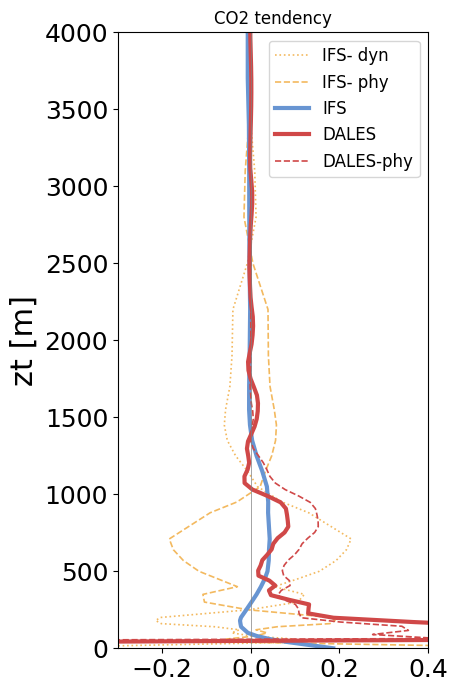

In [12]:
###### CO2 tendency ######
plt.figure(figsize=(4,8))
### IFS
ifs_z_slab['dco2dt_dyn_ppm'].mean('time').plot(
    y='height',label='IFS dyn',c=col[2],lw=1.2,ls=':')
# ifs_z_slab['dco2dt_diff_ppm'].mean('time').plot(
#     y='height',label='IFS- diff',c=col[2],lw=1.2,ls=':')
# ifs_z_slab['dco2dt_conv_ppm'].mean('time').plot(
#     y='height',label='IFS- conv',c=col[2],lw=1.2,ls='--')

(ifs_z_slab['dco2dt_diff_ppm']+ifs_z_slab['dco2dt_conv_ppm']).mean('time').plot(
    y='height',label='IFS phy',c=col[2],lw=1.2,ls='--')

ifs_z_slab['dco2dt_tot_ppm'].mean('time').plot(
    y='height',label='IFS',c=col[1],lw=3)
### DALES
dales_2d['sv004_ppm_ten'].mean('time').plot(
    y='zt',label='DALES',c=col[0],alpha=1,lw=3)
dales_2d['sv001_ppm_ten'].mean('time').plot(
    y='zt',label='DALES Background',c=col[0],alpha=1,lw=3)
(dales_2d['sv004_ppm_ten']-dales_2d['sv001_ppm_ten']).mean('time').plot(
    y='zt',label='DALES - Background ',c=col[0],alpha=1,lw=1.2,ls='--')


plt.axvline(0,c='grey',lw=0.5)
plt.title('CO2 tendency')
plt.legend()
plt.ylim(0,4000)
plt.xlim(-0.3,0.4)

In [ ]:
z_fc_slab_dict[exp]

<xarray.Dataset> Size: 3MB
Dimensions:       (time: 144, height: 41)
Coordinates:
  * time          (time) datetime64[ns] 1kB 2022-05-15T05:00:00 ... 2022-05-2...
  * height        (height) int64 328B 0 10 20 40 60 ... 3700 4000 4500 5000 5500
Data variables: (12/55)
    crwc          (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dudt_dyn      (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dvdt_dyn      (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dTdt_dyn      (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dqdt_dyn      (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dudt_diff     (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    ...            ...
    dqdt_tot      (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dTdt_tot      (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dudt_tot      (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dvdt_tot      (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dco2dt_tot    (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>
    dch4dt_tot    (time, height) float64 47kB dask.array<chunksize=(144, 41), meta=np.ndarray>

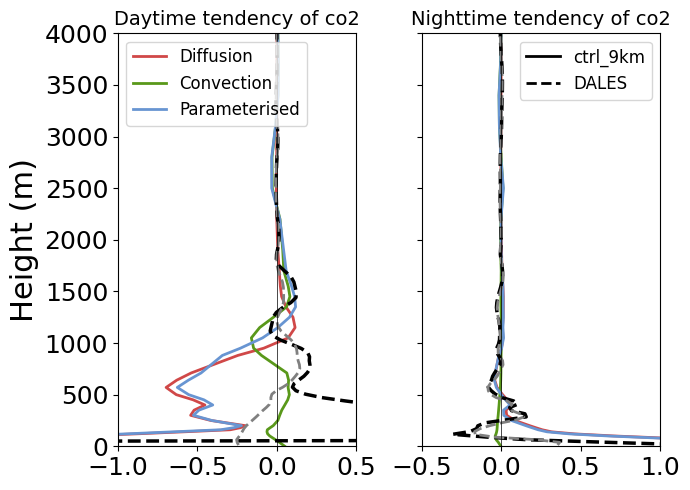

In [58]:
var = 'co2'

fig, axs = plt.subplots(1, 2, figsize=(7, 5), sharey=True)
lines_legend2 = []
for ide, exp in enumerate(['ctrl_9km',]):
    # Collect handles for custom legend
    lines_legend2.append(
        mlines.Line2D([], [], color='k', linestyle=['-', '--'][ide], linewidth=2, label=exp)
    )
    for idt, hours in enumerate([hours_day, hours_night]):
        ds_to_plot = z_fc_slab_dict[exp].sel(time=dales_2d.time)  # Select hours
        ds_to_plot = ds_to_plot.sel(time=ds_to_plot['time'].dt.hour.isin(hours))
        ax = axs[idt]
        # Plot the components with appropriate linestyle
        ds_to_plot[f'd{var}dt_diff'].mean('time').plot(
            y='height', ax=ax, label='Diffusion', c=col[0], lw=2, ls=['-', '--'][ide])
        ds_to_plot[f'd{var}dt_conv'].mean('time').plot(
            y='height', ax=ax, label='Convection', c=col[3], lw=2, ls=['-', '--'][ide])
        (ds_to_plot[f'd{var}dt_conv']+ds_to_plot[f'd{var}dt_diff']).mean('time').plot(
            y='height', ax=ax, label='Parameterised', c=col[1], lw=2, ls=['-', '--'][ide])
        # ds_to_plot[f'd{var}dt_dyn'].mean('time').plot(
        #     y='height', ax=ax, label='Resolved', c=col[2], lw=2, ls=['-', '--'][ide])
        # ds_to_plot[f'd{var}dt_tot'].mean('time').plot(
        #     y='height', ax=ax, label='Total', c='k', lw=2.5, ls=['-', '--'][ide])

    
##### Plot DALES
lines_legend2.append(
    mlines.Line2D([], [], color='k', linestyle= '--', linewidth=2, label='DALES')
)
for idt, hours in enumerate([hours_day, hours_night]):
    ax = axs[idt]
    line_1 =co2_tend_up9km.sel(time=co2_tend_up9km['time'].dt.hour.isin(hours)).mean('time')  # Select hours
    # line_2 =co2_tend_up05km.sel(time=co2_tend_up05km['time'].dt.hour.isin(hours)).mean('time')  # Select hours
    line_3 =ds['sv004']['tot_tend'].sel(time=ds['sv004']['time'].dt.hour.isin(hours)).mean('time')  # Select hours


    line_3.plot(y='zt', ax=ax, lw=2.5, label='DALES Tot', c='k',ls='--')
    line_1.plot(y='zt', ax=ax, lw=2, label='DALES >9km',c='grey',ls='--')
    # line_2.plot(y='zt', ax=ax, lw=2, label='>0.5km')

# Add vertical lines and labels
for ax in axs: 
    ax.axvline(0, c='k', lw=0.5)
    ax.set_ylim([0, 4000])
    ax.set_xlabel('')

# Left panel: legend with only first 3 entries
handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles[:3], labels[:3], loc='upper left')
axs[0].set_title("Daytime tendency of " + var, fontsize=14)
axs[0].set_ylabel('Height (m)')
axs[0].set_xlim([-1, 0.5])

# Right panel: custom legend for line styles
axs[1].legend(handles=lines_legend2, loc='best')
axs[1].set_title("Nighttime tendency of " + var, fontsize=14)
axs[1].set_ylabel('')
axs[1].set_xlim([-0.5, 1])

plt.tight_layout()
plt.show()

KeyError: "No variable named 'dco2dt_diff'. Variables on the dataset include ['time', 'height', 'crwc', 't', 'q', ..., 'ch4', 'co', 'ra', 'pb', 'wspd']"

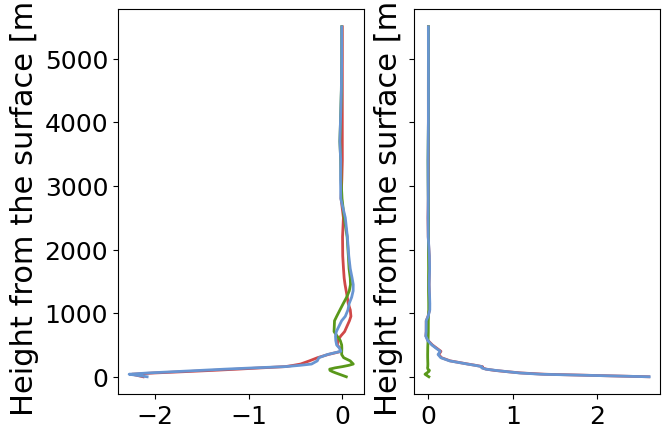

In [90]:
var = 'co2'

fig, axs = plt.subplots(1, 2, figsize=(7, 5), sharey=True)
lines_legend2 = []
for ide, exp in enumerate(['ctrl','TKE']):
    # Collect handles for custom legend
    lines_legend2.append(
        mlines.Line2D([], [], color='k', linestyle=['-', '--'][ide], linewidth=2, label=exp)
    )
    for idt, hours in enumerate([hours_day, hours_night]):
        ds_to_plot = z_fc_slab_dict[exp].sel(time=z_fc_slab_dict[exp]['time'].dt.hour.isin(hours))  # Select hours
        ax = axs[idt]
        # Plot the components with appropriate linestyle
        ds_to_plot[f'd{var}dt_diff'].mean('time').plot(
            y='height', ax=ax, label='Diffusion', c=col[0], lw=2, ls=['-', '--'][ide])
        ds_to_plot[f'd{var}dt_conv'].mean('time').plot(
            y='height', ax=ax, label='Convection', c=col[3], lw=2, ls=['-', '--'][ide])
        (ds_to_plot[f'd{var}dt_conv']+ds_to_plot[f'd{var}dt_diff']).mean('time').plot(
            y='height', ax=ax, label='Parameterised', c=col[1], lw=2, ls=['-', '--'][ide])
        # ds_to_plot[f'd{var}dt_dyn'].mean('time').plot(
        #     y='height', ax=ax, label='Resolved', c=col[2], lw=2, ls=['-', '--'][ide])
        # ds_to_plot[f'd{var}dt_tot'].mean('time').plot(
        #     y='height', ax=ax, label='Total', c='k', lw=2.5, ls=['-', '--'][ide])

# Add vertical lines and labels
for ax in axs: 
    ax.axvline(0, c='k', lw=0.5)
    ax.set_ylim([0, 4000])
    ax.set_xlabel('')

# Left panel: legend with only first 3 entries
handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles[:3], labels[:3], loc='upper left')
axs[0].set_title("Daytime tendency of " + var, fontsize=14)
axs[0].set_ylabel('Height (m)')
axs[0].set_xlim([-1, 0.5])

# Right panel: custom legend for line styles
axs[1].legend(handles=lines_legend2, loc='best')
axs[1].set_title("Nighttime tendency of " + var, fontsize=14)
axs[1].set_ylabel('')
axs[1].set_xlim([-0.5, 1])

plt.tight_layout()
plt.show()

NameError: name 'ifs_z_slab' is not defined

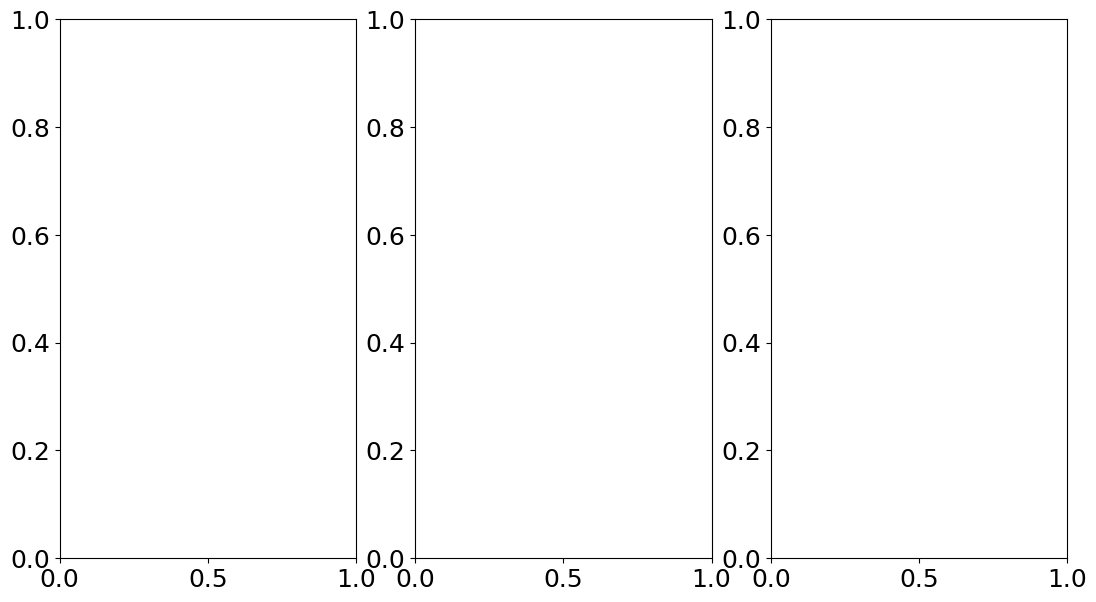

In [39]:
var = 'co2'
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 7))

for idx, hours in enumerate([hours_day,hours_night]):

    ### IFS
    ds_filtered = ifs_z_slab.sel(time=ifs_z_slab['time'].dt.hour.isin(hours))  # Select hours
    ds_mean = ds_filtered.mean('time',keep_attrs=True)
    # tendency
    # ds_mean['d'+var+'dt_dyn_ppm'].plot(ax=axes[idx], y='height', label='IFS- Dyn'  ,c=col[0],
    #                             lw=1.2)
    ds_mean['d'+var+'dt_diff_ppm'].plot(ax=axes[idx],y='height', label='IFS- Diff' ,c=col[1],
                                    lw=1.2)
    ds_mean['d'+var+'dt_conv_ppm'].plot(ax=axes[idx],y='height', label='IFS- Conv' ,c=col[2],
                                    lw=1.2)
    # ds_mean['d'+var+'dt_tot_ppm'].sel(height=slice(70,None)).plot(ax=axes[idx], y='height', label='IFS- Tot'  ,c='k'   ,
    #                             lw=3)
    # concentration
    ds_mean[var+'_ppm'].plot(ax=axes[2], y='height', lw=2, label=['IFS- Day','IFS- Night'][idx],c=['r','b'][idx])


    ### DALES
    dales_filtered = dales_2d.sel(time=dales_2d['time'].dt.hour.isin(hours)) 
    dales_mean = dales_filtered.mean('time',keep_attrs=True)
    # tendency
    dales_mean['sv004_ppm_ten'].plot(ax=axes[idx],
            y='zt',label='DALES',c='k',lw=3,ls='--')
    # concentration
    dales_mean['sv004_ppm'].plot(ax=axes[2],label=['DALES- Day','DALES- Night'][idx],
            y='zt',c=['r','b'][idx],lw=3,ls='--')


for idx in [0,1,2]:
    axes[idx].set_ylim([0,5000])
axes[0].axvline(0,c='grey',lw=0.5)
axes[1].axvline(0,c='grey',lw=0.5)
axes[0].set_xlim([-0.6,0.7])
axes[1].set_xlim([-0.6,0.7])

axes[1].legend(fontsize=16)
axes[2].legend(fontsize=18,loc='upper right')
axes[0].set_ylabel('Height (m)')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])
axes[2].set_ylabel('')
axes[2].set_yticklabels([])
# unit_tend = ds_mean['d'+var+'dt_dyn'].attrs.get('units', '')
# unit_conc = ds_mean[var].attrs.get('units', '')
unit_tend = r'ppm h$^{-1}$'
unit_conc = r'ppm'
axes[0].set_xlabel(f'Tendency ({unit_tend})')
axes[1].set_xlabel(f'Tendency ({unit_tend})')
axes[2].set_xlabel(f'Concentration ({unit_conc})')
# Set scientific notation on the x-axis
axes[0].ticklabel_format(axis='x', style='sci', scilimits=(-3,3))
axes[1].ticklabel_format(axis='x', style='sci', scilimits=(-3,3))
# axes[0].set_title('Budget of '+var.upper(), fontsize =22)
axes[0].set_title('Daytime budget', fontsize =22)
axes[1].set_title('Nighttime budget', fontsize =22)
axes[2].set_title('Concentration of '+var.upper(), fontsize =22)

plt.tight_layout()

KeyError: "No variable named 'thl'. Variables on the dataset include ['time', 'height', 'crwc', 't', 'q', ..., 'co', 'ra', 'pb', 'co2_ppm', 'wspd']"

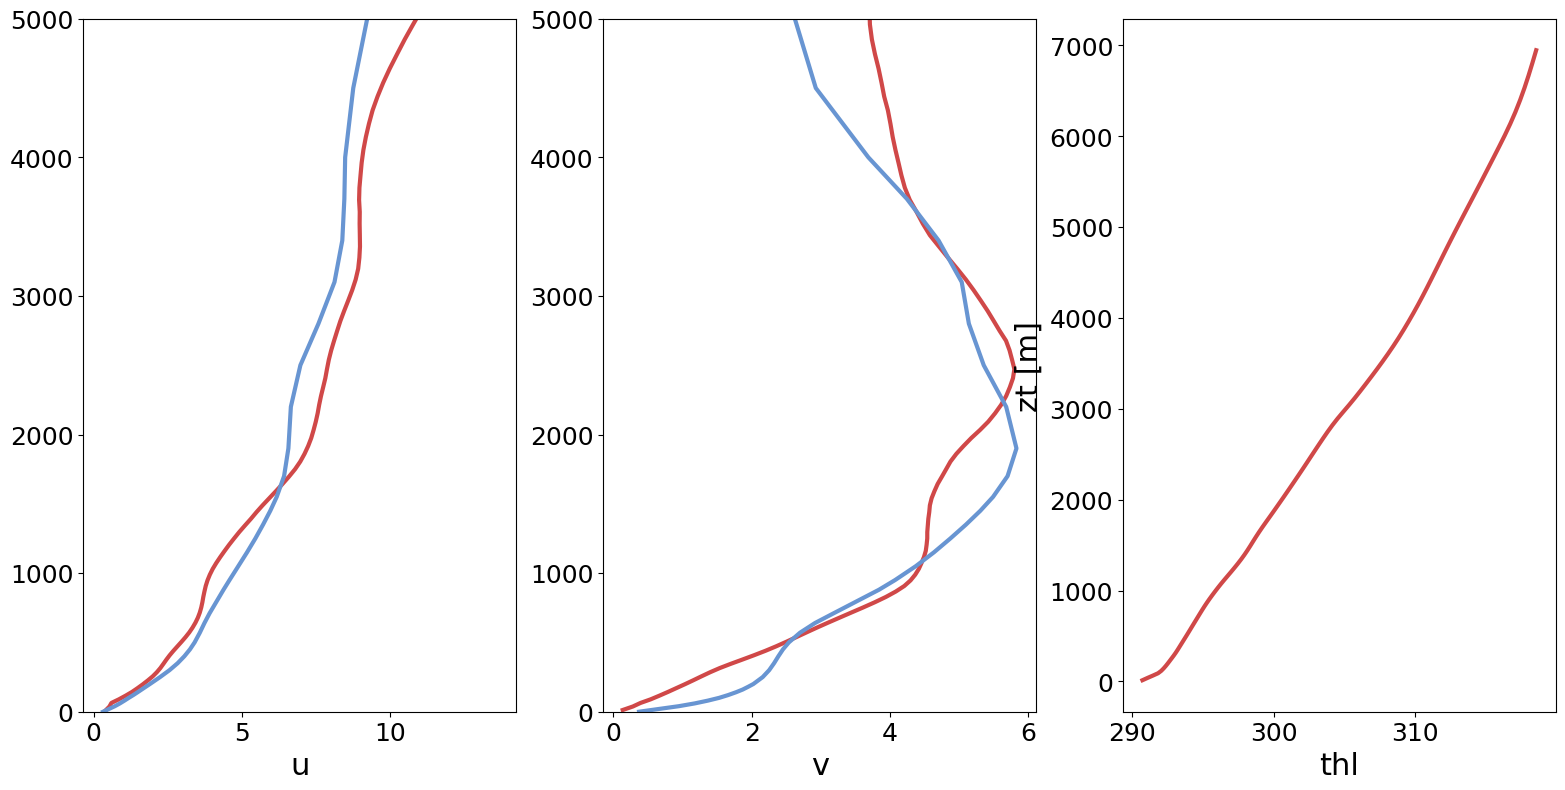

In [ ]:
## PROFILES OF METEOROLOGY ##
vars = ['u','v']
fig, axes = plt.subplots(nrows=1, ncols=len(vars), figsize=(19, 9),
                        #  sharex=True
                         )

for idx,var in enumerate(vars):
    ### DALES
    dales_2d[var].mean('time').plot(ax=axes[idx],
        y='zt',label='DALES',c=col[0],alpha=1,lw=3)
    # Add shading for standard deviation
    # std_profile = dales_3d[var].std(('xt', 'yt'))
    # plt.fill_betweenx(dales_2d['zt'],  (dales_2d[var] - std_profile).mean('time'), (dales_2d[var] + std_profile).mean('time'),
    #                   color=col[0], alpha=0.3)
    ### IFS
    ifs_z_slab[var].mean('time').plot(ax=axes[idx],
        y='height',label='IFS',c=col[1],lw=3)
    # Add shading for standard deviation
    # std_profile = ifs_z[var].std(('latitude', 'longitude'))
    # plt.fill_betweenx(ifs_z_slab['height'], (ifs_z_slab[var] - std_profile).mean('time'), (ifs_z_slab[var] + std_profile).mean('time'),
    #                   color=col[1], alpha=0.3)

    axes[idx].set_ylim(0,5000)
    axes[idx].set_ylabel('')

axes[0].legend()


In [ ]:
### EVOLUTION IN CLOUD LAYER ###

<xarray.Dataset> Size: 132MB
Dimensions:      (zt: 104, zts: 4, time: 2880)
Coordinates:
  * zt           (zt) float32 416B 12.5 37.71 63.35 ... 6.807e+03 6.948e+03
  * zts          (zts) float32 16B -1.945 -0.64 -0.175 -0.035
  * time         (time) datetime64[ns] 23kB 2022-05-18T00:01:00 ... 2022-05-20
Data variables: (12/110)
    rhof         (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    rhobf        (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    rhobh        (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    presh        (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    u            (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    v            (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    ...           ...
    svp004_ppm   (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    svpt004_ppm  (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    sv0042r_ppm  (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    wsv004s_ppm  (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    wsv004r_ppm  (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
    wsv004t_ppm  (time, zt) float32 1MB dask.array<chunksize=(1, 104), meta=np.ndarray>
Attributes:
    title:    profiles.001.nc
    history:  Created on 20241110 at 124848.409
    Source:   DALES 4.2 git:
    Author: